<a href="https://colab.research.google.com/github/PALAK7890/SectionA_Team14_JobMarketTrends/blob/main/notebooks/04_statistical_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
data='https://raw.githubusercontent.com/PALAK7890/SectionA_Team14_JobMarketTrends/refs/heads/main/Dataset/postings_tableau_ready.csv'

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df=pd.read_csv(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120484 entries, 0 to 120483
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      120484 non-null  int64  
 1   company_name                120484 non-null  object 
 2   title                       120484 non-null  object 
 3   job_category                120484 non-null  object 
 4   formatted_experience_level  120484 non-null  object 
 5   formatted_work_type         120484 non-null  object 
 6   remote_label                120484 non-null  object 
 7   location                    120484 non-null  object 
 8   state                       120484 non-null  object 
 9   normalized_salary           35081 non-null   float64
 10  salary_bracket              120484 non-null  object 
 11  pay_period                  120484 non-null  object 
 12  views                       120484 non-null  int64  
 13  applies       

In [ ]:
df.head()

,job_id,company_name,title,job_category,formatted_experience_level,formatted_work_type,remote_label,location,state,normalized_salary,...,application_type,listing_month,listing_month_name,listing_year,listing_dayofweek,original_listed_date,expiry_date,experience_order,salary_bracket_order,month_order
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Marketing,Unspecified,Full-time,On-Site,"Princeton, NJ",NJ,38480.0,...,ComplexOnsiteApply,4,Apr,2024,Wednesday,2024-04-17,2024-05-17,7,1,5
1,10998357,The National Exemplar,Assitant Restaurant Manager,Management,Unspecified,Full-time,On-Site,"Cincinnati, OH",OH,55000.0,...,ComplexOnsiteApply,4,Apr,2024,Tuesday,2024-04-16,2024-05-16,7,2,5
2,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Other,Unspecified,Full-time,On-Site,"New Hyde Park, NY",NY,157500.0,...,ComplexOnsiteApply,4,Apr,2024,Friday,2024-04-12,2024-05-12,7,6,5
3,91700727,Downtown Raleigh Alliance,Economic Development and Planning Intern,Other,Unspecified,Internship,On-Site,"Raleigh, NC",NC,35360.0,...,ComplexOnsiteApply,4,Apr,2024,Thursday,2024-04-18,2024-05-18,7,1,5
4,103254301,Raw Cereal,Producer,Other,Unspecified,Contract,Remote,United States,National,180000.0,...,SimpleOnsiteApply,4,Apr,2024,Thursday,2024-04-11,2024-05-11,7,6,5


In [ ]:
remote = df[df['remote_label'] == 'Remote']['normalized_salary'].dropna()
onsite = df[df['remote_label'] != 'Remote']['normalized_salary'].dropna()

from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(remote, onsite, equal_var=False)

print("P-value:", p_value)

P-value: 2.6097466316488044e-196


In [ ]:
from scipy.stats import f_oneway

groups = [group['normalized_salary'].dropna()
          for name, group in df.groupby('job_category')]

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 0.0


In [ ]:
groups = [group['normalized_salary'].dropna()
          for name, group in df.groupby('formatted_experience_level')]

f_stat, p_value = f_oneway(*groups)

In [ ]:
from scipy.stats import pearsonr

df_clean = df.dropna(subset=['views','applies'])

corr, p_value = pearsonr(df_clean['views'], df_clean['applies'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.49130906204581115
P-value: 0.0


In [ ]:
df['demand_segment'] = pd.qcut(df['views'], 4,
                              labels=['Low','Medium','High','Very High'])

In [ ]:
salary_df = df[df['normalized_salary'].notnull()]

salary_df['salary_segment'] = pd.qcut(salary_df['normalized_salary'], 4)

/tmp/ipykernel_3683/1285825524.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salary_df['salary_segment'] = pd.qcut(salary_df['normalized_salary'], 4)


In [ ]:
df['competition'] = df['applies'] / df['views'].replace(0, np.nan)
df['efficiency'] = df['applies'] / df['days_active'].replace(0, np.nan)

In [ ]:
df.groupby('job_category')[['views','normalized_salary']].mean()

,views,normalized_salary
job_category,,
Customer Service,12.499118,51357.142360
Data & Analytics,24.105263,144382.752679
Education,7.014103,67788.107847
Finance & Accounting,20.809063,102008.283752
HR & Recruiting,29.452064,73181.882206
Healthcare,7.751870,102424.153725
Logistics & Supply Chain,6.653042,52824.889235
Management,17.954883,118107.543885
Marketing,37.891405,102935.625036


In [ ]:
df['efficiency'] = df['applies'] / df['days_active']

df['efficiency'].describe()

,efficiency
count,22885.000000
mean,0.322279
std,0.870805
min,0.004484
25%,0.033333
50%,0.068966
75%,0.233333
max,18.866667


In [ ]:
df.groupby(['job_category','remote_label'])['normalized_salary'].mean()

job_category              remote_label
Customer Service          On-Site          50876.765230
                          Remote           53806.337879
Data & Analytics          On-Site         142916.149351
                          Remote          147609.280000
Education                 On-Site          66287.478245
                          Remote           91723.150000
Finance & Accounting      On-Site         101732.950129
                          Remote          103668.592974
HR & Recruiting           On-Site          69238.987716
                          Remote          103387.270357
Healthcare                On-Site          98891.714832
                          Remote          131947.002396
Logistics & Supply Chain  On-Site          52295.323457
                          Remote           96971.418182
Management                On-Site         115074.036901
                          Remote          136233.635683
Marketing                 On-Site         101279.560650
                          Remote          106955.532365
Other                     On-Site          76962.253229
                          Remote          105966.574081
Sales                     On-Site          79816.661435
                          Remote          120160.250524
Technology                On-Site         129066.894358
                          Remote          139025.316284
Trades & Technical        On-Site          63350.759688
                          Remote           79529.394118
Name: normalized_salary, dtype: float64

In [ ]:
trend = df.groupby(['listing_year','listing_month'])['job_id'].count().reset_index()

trend['time'] = range(len(trend))

from sklearn.linear_model import LinearRegression

X = trend[['time']]
y = trend['job_id']

model = LinearRegression()
model.fit(X, y)

trend['forecast'] = model.predict(X)

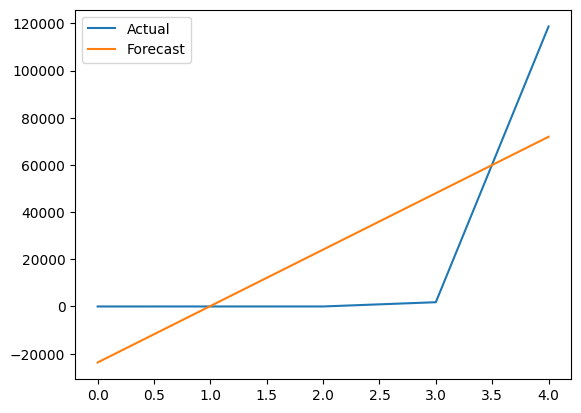

In [ ]:
import matplotlib.pyplot as plt

plt.plot(trend['time'], trend['job_id'], label='Actual')
plt.plot(trend['time'], trend['forecast'], label='Forecast')
plt.legend()
plt.show()